

---

## 🎯 Objetivos del Práctico: Regularización en Modelos de Regresión

### Objetivo General
- Aplicar técnicas de regularización en modelos de regresión lineal para mejorar la estabilidad, interpretabilidad y capacidad predictiva ante multicolinealidad y sobreajuste.

### Objetivos Específicos
- 🧮 Implementar los métodos Ridge, Lasso y ElasticNet en Python utilizando `scikit-learn`.
- 📊 Comparar el comportamiento de los coeficientes estimados bajo diferentes penalizaciones.
- 🔍 Evaluar el impacto de la regularización sobre el error de predicción y la selección de variables.
- 🧪 Simular escenarios con multicolinealidad para observar cómo cada método responde a redundancia informativa.
- 📈 Visualizar y analizar gráficamente la evolución de los coeficientes en función del parámetro de penalización $\alpha$ Regularización en Modelos de Regresión).
- 🧾 Documentar el proceso de modelado y selección en un formato reproducible y adaptable para publicación académica.

---

## 📐 Formalización Breve


**Modelo base:** Regresión lineal múltiple

$
y_i = \beta_0 + \sum_{j=1}^{p} \beta_j x_{ij} + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)
$

**Ridge (L2):** Penaliza la suma de cuadrados de los coeficientes

$
\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \right\}
$

Lasso (L1): Penaliza la suma absoluta de los coeficientes

$
\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right\}
$

**ElasticNet (L1 + L2): ** Combina ambas penalizaciones

$
\min_{\boldsymbol{\beta}} \left\{ \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \left[ \alpha \sum_{j=1}^{p} |\beta_j| + (1 - \alpha) \sum_{j=1}^{p} \beta_j^2 \right] \right\}
$


**Interpretación:**
- Ridge reduce la magnitud de los coeficientes pero no los elimina.  
- Lasso puede eliminar variables irrelevantes (selección automática).  
- ElasticNet equilibra ambos efectos, útil cuando hay muchas variables correlacionadas.

---


## ⚙️ Preparación: Simulación de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Simular datos con ruido y multicolinealidad
np.random.seed(42)
n = 100
X = np.random.rand(n, 5)
X[:, 2] = X[:, 1] + np.random.normal(0, 0.01, n)  # alta correlación entre X1 y X2
coef_true = np.array([3, -2, 0, 0, 1])
y = X @ coef_true + np.random.normal(0, 0.5, n)

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

---

## 📐 Regresión Lineal sin regularización

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Coeficientes OLS:", lr.coef_)
print("MSE:", mean_squared_error(y_test, y_pred_lr))

Coeficientes OLS: [ 3.14595474  3.92261261 -6.22388907  0.17993894  0.88407821]
MSE: 0.4198497445152924


---

## 🧊 Ridge (penalización L2)


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

print("Coeficientes Ridge:", ridge.coef_)
print("MSE:", mean_squared_error(y_test, y_pred_ridge))

Coeficientes Ridge: [ 2.73869081 -1.06773903 -1.12097858  0.15358694  0.76907547]
MSE: 0.32249107857054327


## 🧲 Lasso (penalización L1)

In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

print("Coeficientes Lasso:", lasso.coef_)
print("MSE:", mean_squared_error(y_test, y_pred_lasso))

Coeficientes Lasso: [ 1.96256654 -0.         -1.40275828  0.          0.        ]
MSE: 0.31973204807694383


---

## 🧮 ElasticNet (combinación L1 + L2)

In [ ]:
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)
y_pred_elastic = elastic.predict(X_test)

print("Coeficientes ElasticNet:", elastic.coef_)
print("MSE:", mean_squared_error(y_test, y_pred_elastic))

Coeficientes ElasticNet: [ 1.59396419 -0.76961595 -0.78242649  0.          0.2196057 ]
MSE: 0.3510455418410404


## 📊 Comparación visual de coeficientes

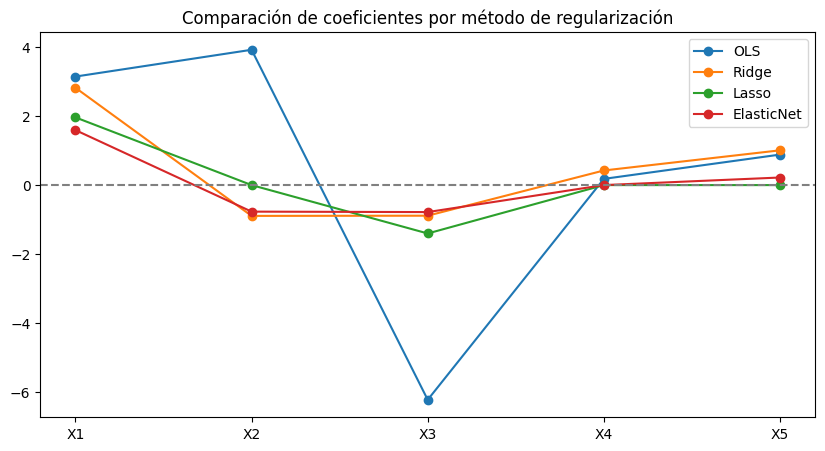

In [ ]:
labels = [f'X{i+1}' for i in range(X.shape[1])]
plt.figure(figsize=(10, 5))
plt.plot(labels, lr.coef_, label='OLS', marker='o')
plt.plot(labels, ridge.coef_, label='Ridge', marker='o')
plt.plot(labels, lasso.coef_, label='Lasso', marker='o')
plt.plot(labels, elastic.coef_, label='ElasticNet', marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.title("Comparación de coeficientes por método de regularización")
plt.show()

---

## 📊 Trayectoria de Coeficientes con Regularización

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Simular datos
np.random.seed(42)
n = 100
X = np.random.rand(n, 5)
X[:, 2] = X[:, 1] + np.random.normal(0, 0.01, n)  # multicolinealidad
coef_true = np.array([3, -2, 0, 0, 1])
y = X @ coef_true + np.random.normal(0, 0.5, n)

# Valores de alpha para explorar
alphas = np.logspace(-3, 1, 50)

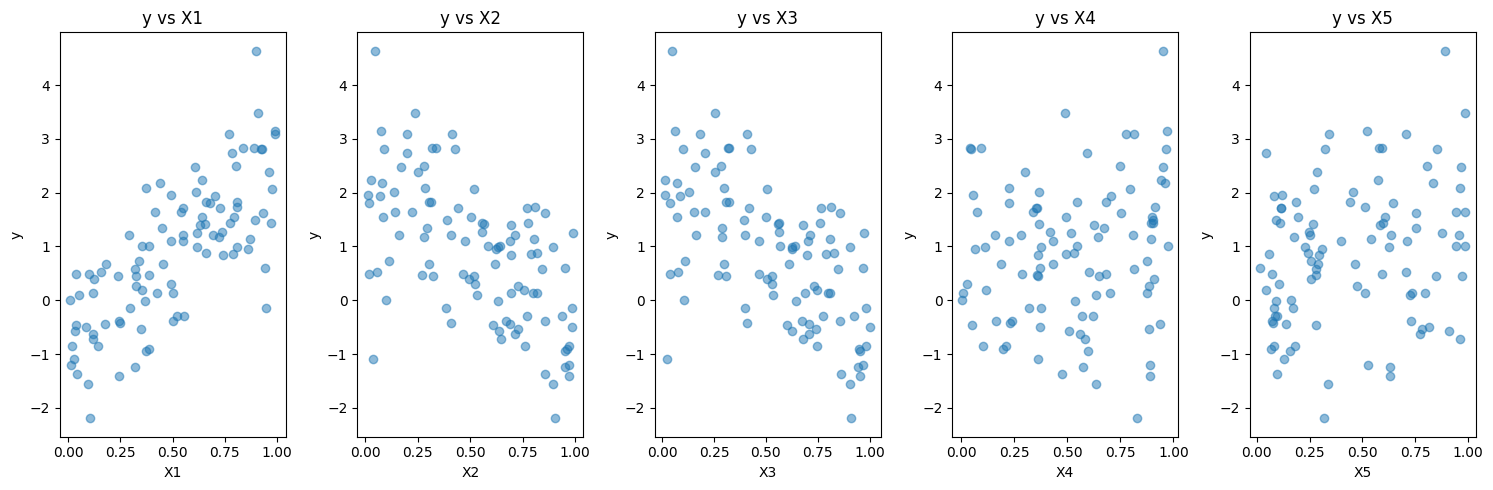

In [ ]:
# Visualize y vs X
plt.figure(figsize=(15, 5))
for i in range(X.shape[1]):
    plt.subplot(1, X.shape[1], i + 1)
    plt.scatter(X[:, i], y, alpha=0.5)
    plt.title(f'y vs X{i+1}')
    plt.xlabel(f'X{i+1}')
    plt.ylabel('y')
plt.tight_layout()
plt.show()

In [ ]:

# RidgeCV
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X, y)

# LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5)
lasso_cv.fit(X, y)

# ElasticNetCV
elastic_cv = ElasticNetCV(alphas=alphas, l1_ratio=0.5, cv=5)
elastic_cv.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


ElasticNetCV(alphas=array([1.00000000e-03, 1.20679264e-03, 1.45634848e-03, 1.75751062e-03,
       2.12095089e-03, 2.55954792e-03, 3.08884360e-03, 3.72759372e-03,
       4.49843267e-03, 5.42867544e-03, 6.55128557e-03, 7.90604321e-03,
       9.54095476e-03, 1.15139540e-02, 1.38949549e-02, 1.67683294e-02,
       2.02358965e-02, 2.44205309e-02, 2.94705170e-02, 3.55648031e-02,
       4.29193426e-02, 5.179474...
       9.10298178e-02, 1.09854114e-01, 1.32571137e-01, 1.59985872e-01,
       1.93069773e-01, 2.32995181e-01, 2.81176870e-01, 3.39322177e-01,
       4.09491506e-01, 4.94171336e-01, 5.96362332e-01, 7.19685673e-01,
       8.68511374e-01, 1.04811313e+00, 1.26485522e+00, 1.52641797e+00,
       1.84206997e+00, 2.22299648e+00, 2.68269580e+00, 3.23745754e+00,
       3.90693994e+00, 4.71486636e+00, 5.68986603e+00, 6.86648845e+00,
       8.28642773e+00, 1.00000000e+01]),
             cv=5)

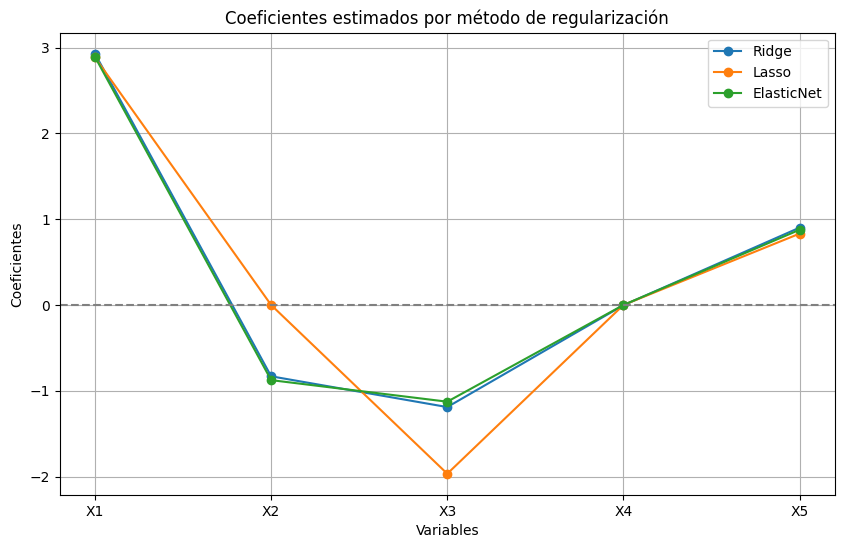

Mejor alpha Ridge: 0.1326
Mejor alpha Lasso: 0.0079
Mejor alpha ElasticNet: 0.0037


In [ ]:

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(ridge_cv.coef_, label='Ridge', marker='o')
plt.plot(lasso_cv.coef_, label='Lasso', marker='o')
plt.plot(elastic_cv.coef_, label='ElasticNet', marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Coeficientes estimados por método de regularización")
plt.xlabel("Variables")
plt.ylabel("Coeficientes")
plt.xticks(ticks=range(X.shape[1]), labels=[f'X{i+1}' for i in range(X.shape[1])])
plt.legend()
plt.grid(True)
plt.show()

# Mejor alpha por método
print(f"Mejor alpha Ridge: {ridge_cv.alpha_:.4f}")
print(f"Mejor alpha Lasso: {lasso_cv.alpha_:.4f}")
print(f"Mejor alpha ElasticNet: {elastic_cv.alpha_:.4f}")

In [ ]:
# Perform bootstrapping for the Ridge model
n_bootstrap_samples = 1000  # You can adjust the number of samples
confidence_level = 0.95
ridge_confidence_intervals = bootstrap_coefficients(ridge, X_train, y_train, n_bootstrap_samples, confidence_level)

print("Ridge Coefficient Confidence Intervals (95%):")
for i, (lower, upper) in enumerate(ridge_confidence_intervals):
    print(f"X{i+1}: ({lower:.4f}, {upper:.4f})")

Ridge Coefficient Confidence Intervals (95%):
X1: (2.3355, 3.0878)
X2: (-1.2723, -0.8702)
X3: (-1.3455, -0.8927)
X4: (-0.1910, 0.4760)
X5: (0.4376, 1.0994)


In [ ]:
def bootstrap_coefficients(model, X, y, n_bootstrap_samples, confidence_level):
    """
    Performs bootstrapping to estimate coefficient confidence intervals.

    Args:
        model: The scikit-learn regression model (fitted).
        X: Feature data.
        y: Target data.
        n_bootstrap_samples: Number of bootstrap samples to draw.
        confidence_level: The desired confidence level (e.g., 0.95 for 95%).

    Returns:
        A list of tuples, where each tuple contains the lower and upper
        bound of the confidence interval for each coefficient.
    """
    n_samples = X.shape[0]
    n_features = X.shape[1]
    bootstrapped_coefs = np.zeros((n_bootstrap_samples, n_features))

    for i in range(n_bootstrap_samples):
        # Sample with replacement
        bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_sample, y_sample = X[bootstrap_indices], y[bootstrap_indices]

        # Fit the model on the bootstrap sample
        bootstrapped_model = model.__class__(**model.get_params()) # Create new instance with same params
        bootstrapped_model.fit(X_sample, y_sample)
        bootstrapped_coefs[i, :] = bootstrapped_model.coef_

    # Calculate confidence intervals (percentiles)
    alpha = 100 * (1 - confidence_level)
    lower_percentile = alpha / 2
    upper_percentile = 100 - alpha / 2

    confidence_intervals = []
    for j in range(n_features):
        lower_bound = np.percentile(bootstrapped_coefs[:, j], lower_percentile)
        upper_bound = np.percentile(bootstrapped_coefs[:, j], upper_percentile)
        confidence_intervals.append((lower_bound, upper_bound))

    return confidence_intervals



---

Este ejemplo permite observar cómo cada método ajusta los coeficientes en presencia de multicolinealidad y ruido, y cómo selecciona el mejor valor de penalización mediante validación cruzada.


